# GTEx projection into ARCHS4 CLAMP — Tissue ARI comparison (k-means)

💡 **Environment:** `gpu-kmeans`

In [1]:
import csv
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from pyprojroot.here import here
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import cupy as cp
from cuml.cluster import KMeans as cuKMeans
import matplotlib.pyplot as plt
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import re
from scipy.stats import mannwhitneyu
import yaml

readRDS = ro.r["readRDS"]

In [2]:
with open(here("config.yaml"), "r") as f:
    _cfg = yaml.safe_load(f)

MODEL_COLORS = _cfg["MODEL_COLORS"]
RNASEQ_FRACTION_COLORS = _cfg["RNASEQ_FRACTION_COLORS"]

def get_model_color(model_name):
    return MODEL_COLORS.get(model_name, "#333333")

def get_fraction_color(fraction_label):
    return RNASEQ_FRACTION_COLORS.get(str(fraction_label), "#333333")

# Input

In [3]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,
    engine='python',
    comment=None,
    keep_default_na=False,
    on_bad_lines='warn'
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [4]:
display(gtex_meta['SMTS'].value_counts())
total_tissues = len(gtex_meta['SMTS'].value_counts())
total_tissues

SMTS
Blood              3480
Brain              3326
Skin               2014
Esophagus          1582
Blood Vessel       1473
Adipose Tissue     1327
Heart              1141
Muscle             1132
Lung                867
Colon               821
Thyroid             812
Nerve               722
Breast              480
Testis              406
Stomach             381
Pancreas            360
Pituitary           301
Adrenal Gland       275
Prostate            262
Spleen              260
Liver               251
Bone Marrow         217
Ovary               195
Small Intestine     193
Salivary Gland      181
Vagina              173
Uterus              166
Kidney              104
Bladder              21
Cervix Uteri         19
Fallopian Tube        9
Name: count, dtype: int64

31

In [5]:
# z-scored, filtered GTEx expression
gtex_data = pd.read_csv(here('output/gtex/df_gtex_fbm_filt.csv'), index_col=0)

In [6]:
meta = gtex_meta.copy()
if meta.index.name != "SAMPID":
    meta = meta.set_index("SAMPID")

sample_ids_expr = pd.Index(gtex_data.columns.astype(str).str.strip(), name="SAMPID")
sample_ids_meta = meta.index.astype(str).str.strip()
common_ids = sample_ids_expr.intersection(sample_ids_meta)

if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between expression and metadata.")

gtex_data_common = gtex_data.loc[:, common_ids]
meta_common = meta.loc[common_ids]

In [7]:
y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# GPU k-means ensemble

## Parameters

In [8]:
BASE_SEED    = 10000
K_MIN        = 20
K_MAX        = 40
K_STEP       = 5
N_REPS_PER_K = 50
KMEANS_N_INIT = 10

k_values = list(range(K_MIN, K_MAX + 1, K_STEP))
if total_tissues not in k_values:
    k_values.append(total_tissues)
k_values = sorted(set(k_values))

print("BASE_SEED:",    BASE_SEED)
print("K_MIN:",        K_MIN)
print("K_MAX:",        K_MAX)
print("K_STEP:",       K_STEP)
print("N_REPS_PER_K:", N_REPS_PER_K)
print("total_tissues:", total_tissues)
print("k_values:",     k_values)

BASE_SEED: 10000
K_MIN: 20
K_MAX: 40
K_STEP: 5
N_REPS_PER_K: 50
total_tissues: 31
k_values: [20, 25, 30, 31, 35, 40]


In [9]:
def run_kmeans_compare_scaling(B_t, y_true, method_name):
    """
    Run k-means clustering with and without StandardScaler.
    Returns the best approach based on mean ARI at optimal k.

    Parameters
    ----------
    B_t : array-like
        Transposed data matrix (samples x features)
    y_true : array-like
        True labels for ARI computation
    method_name : str
        Name of the method (for labeling results)

    Returns
    -------
    dict with keys: best_results_df, best_k_results_df, best_k,
                    best_approach, scaled_ari, unscaled_ari, all_results
    """
    results = {}

    for approach in ['scaled', 'unscaled']:
        if approach == 'scaled':
            scaler = StandardScaler()
            X = scaler.fit_transform(B_t)
        else:
            X = B_t.values if hasattr(B_t, 'values') else B_t

        X_gpu = cp.asarray(X.astype("float32"))

        records = []
        for k in k_values:
            for rep in range(N_REPS_PER_K):
                km = cuKMeans(
                    n_clusters=k,
                    init="k-means++",
                    random_state=BASE_SEED + k * 1000 + rep,
                    max_iter=300,
                    tol=1e-4,
                    verbose=0
                )
                labels_gpu = km.fit_predict(X_gpu)
                labels = cp.asnumpy(labels_gpu)
                ari = adjusted_rand_score(y_true, labels)

                records.append({
                    "k": k,
                    "rep": rep,
                    "seed": BASE_SEED + k * 1000 + rep,
                    "ari": ari,
                    "approach": approach
                })

        del X_gpu
        cp.get_default_memory_pool().free_all_blocks()

        df = pd.DataFrame.from_records(records)
        mean_ari = df.groupby("k")["ari"].mean()
        best_k = mean_ari.idxmax()
        best_k_df = df[df["k"] == best_k]

        results[approach] = {
            'df': df,
            'best_k': best_k,
            'best_k_df': best_k_df,
            'best_k_mean_ari': mean_ari[best_k]
        }

    if results['scaled']['best_k_mean_ari'] >= results['unscaled']['best_k_mean_ari']:
        best_approach = 'scaled'
    else:
        best_approach = 'unscaled'

    best = results[best_approach]

    print(f"{method_name}:")
    print(f"  Scaled   - Best k: {results['scaled']['best_k']}, Mean ARI: {results['scaled']['best_k_mean_ari']:.4f}")
    print(f"  Unscaled - Best k: {results['unscaled']['best_k']}, Mean ARI: {results['unscaled']['best_k_mean_ari']:.4f}")
    print(f"  Selected: {best_approach.upper()}")

    return {
        'best_results_df':    best['df'],
        'best_k_results_df':  best['best_k_df'],
        'best_k':             best['best_k'],
        'best_approach':      best_approach,
        'scaled_ari':         results['scaled']['best_k_mean_ari'],
        'unscaled_ari':       results['unscaled']['best_k_mean_ari'],
        'all_results':        results
    }

## RNA-Seq

Sweep all gene fractions by variance; the fraction with the best mean ARI is carried forward.

In [10]:
GENE_FRACTIONS = [1.0, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01]

B = gtex_data.copy()
B.columns = B.columns.astype(str).str.strip()
common_ids = B.columns.intersection(meta.index)
B_common = B.loc[:, common_ids]

all_genes = B_common.index.tolist()
n_genes = len(all_genes)
y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

gene_variances = B_common.var(axis=1)
genes_by_variance = gene_variances.sort_values(ascending=False).index.tolist()

print(f"Total genes: {n_genes}")
print(f"Total samples: {len(common_ids)}")

rnaseq_topvar_results = {}

for frac in GENE_FRACTIONS:
    pct = int(frac * 100)
    run_label = f"rnaseq_{pct}pct_topvar"
    print(f"\n{'='*50}")
    print(f"Running: {run_label}")

    n_select = int(n_genes * frac)
    selected_genes = genes_by_variance[:n_select]
    print(f"  Selected top {n_select} most variable genes")

    B_subset = B_common.loc[selected_genes, :]
    B_t = B_subset.T.astype(np.float32)

    results = run_kmeans_compare_scaling(B_t, y_true, run_label)
    rnaseq_topvar_results[run_label] = results

print("\n" + "="*50)
print("\nTop Variable Genes Analysis Summary:")
for label, results in rnaseq_topvar_results.items():
    best = results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']
    print(f"  {label}: best_approach={results['best_approach']}, best_k={results['best_k']}, ARI={best:.4f}")

Total genes: 21613
Total samples: 17382

Running: rnaseq_100pct_topvar
  Selected top 21613 most variable genes
rnaseq_100pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.6023
  Unscaled - Best k: 25, Mean ARI: 0.6023
  Selected: SCALED

Running: rnaseq_75pct_topvar
  Selected top 16209 most variable genes
rnaseq_75pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.6096
  Unscaled - Best k: 25, Mean ARI: 0.6096
  Selected: SCALED

Running: rnaseq_50pct_topvar
  Selected top 10806 most variable genes
rnaseq_50pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.6063
  Unscaled - Best k: 25, Mean ARI: 0.6063
  Selected: SCALED

Running: rnaseq_25pct_topvar
  Selected top 5403 most variable genes
rnaseq_25pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.5301
  Unscaled - Best k: 25, Mean ARI: 0.5301
  Selected: SCALED

Running: rnaseq_10pct_topvar
  Selected top 2161 most variable genes
rnaseq_10pct_topvar:
  Scaled   - Best k: 30, Mean ARI: 0.4613
  Unscaled - Best k: 30, Mean ARI: 0.4613
  Se

In [11]:
# Pick the fraction with the highest mean ARI
best_mean_ari  = -1
best_run_label = None

for run_label, results in rnaseq_topvar_results.items():
    ari_val = results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']
    if ari_val > best_mean_ari:
        best_mean_ari  = ari_val
        best_run_label = run_label

print(f"Best RNA-Seq configuration: {best_run_label}")
print(f"  Approach:  {rnaseq_topvar_results[best_run_label]['best_approach']}")
print(f"  Best k:    {rnaseq_topvar_results[best_run_label]['best_k']}")
print(f"  Mean ARI:  {best_mean_ari:.4f}")

gtex_rnaseq_results             = rnaseq_topvar_results[best_run_label]
gtex_rnaseq_kmeans_results_df   = gtex_rnaseq_results['best_results_df']
best_k_gtex_rnaseq_kmeans_results_df = gtex_rnaseq_results['best_k_results_df']

best_k_rnaseq_results = {}
for run_label, results in rnaseq_topvar_results.items():
    pct  = int(run_label.split('_')[1].replace('pct', ''))
    frac = pct / 100.0
    df   = results['best_k_results_df'].copy()
    df['frac'] = frac
    best_k_rnaseq_results[run_label] = df

Best RNA-Seq configuration: rnaseq_75pct_topvar
  Approach:  scaled
  Best k:    25
  Mean ARI:  0.6096


## GTEx CLAMP C2CP

In [12]:
gtex_C2CP_CLAMP_rds = readRDS(str(here('output/gtex/gtex_C2CP_CLAMP.rds')))

def extract_B_matrix(rds_obj):
    """Extract B matrix from RDS CLAMP object and return as DataFrame (LVs x samples)."""
    B_matrix = rds_obj.rx2("B")
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    return pd.DataFrame(
        data=B_values,
        index=list(B_matrix.rownames) if B_matrix.rownames else None,
        columns=list(B_matrix.colnames) if B_matrix.colnames else None,
    )

gtex_C2CP_CLAMP = extract_B_matrix(gtex_C2CP_CLAMP_rds)

In [13]:
B = gtex_C2CP_CLAMP.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

gtex_C2CP_CLAMP_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_C2CP_CLAMP")

gtex_C2CP_CLAMP_kmeans_results_df      = gtex_C2CP_CLAMP_results['best_results_df']
best_k_gtex_C2CP_CLAMP_kmeans_results_df = gtex_C2CP_CLAMP_results['best_k_results_df']

gtex_C2CP_CLAMP:
  Scaled   - Best k: 20, Mean ARI: 0.6487
  Unscaled - Best k: 25, Mean ARI: 0.6299
  Selected: SCALED


## ARCHS4 CLAMP projection

In [14]:
# Load projection produced by 00_gtex_archs4_projection.ipynb
projection_path = here('output/archs4/gtex_archs4_C2CP_projection.csv')
archs4_proj = pd.read_csv(projection_path, index_col=0)
archs4_proj.columns = archs4_proj.columns.astype(str).str.strip()
print(f"Projection: {archs4_proj.shape[0]} LVs x {archs4_proj.shape[1]} samples")
archs4_proj.iloc[:5, :5]

Projection: 96 LVs x 17382 samples


,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN
LV2,-6.153790,-1.814750,-5.055878,-6.160825,0.742564
LV4,-12.438905,-25.602459,-15.007495,-12.781571,-31.029736
LV6,65.840233,12.109093,60.622496,87.819814,29.766216
LV10,25.501584,-1.716753,24.335741,24.988439,-19.293597
LV16,14.311432,-1.826006,2.895074,15.943082,-1.985248


In [15]:
B = archs4_proj.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between ARCHS4 projection and metadata.")

print(f"ARCHS4 projection common samples: {len(common_ids)}")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

archs4_proj_results = run_kmeans_compare_scaling(B_t, y_true, "archs4_C2CP_projection")

archs4_proj_kmeans_results_df         = archs4_proj_results['best_results_df']
best_k_archs4_proj_kmeans_results_df  = archs4_proj_results['best_k_results_df']

ARCHS4 projection common samples: 17382
archs4_C2CP_projection:
  Scaled   - Best k: 30, Mean ARI: 0.4356
  Unscaled - Best k: 40, Mean ARI: 0.3162
  Selected: SCALED


## Randomized-Z ARCHS4 projection (null baseline)

In [16]:
# Load randomized-Z projection produced by 00_gtex_archs4_projection.ipynb
rand_proj_path = here('output/archs4/gtex_archs4_C2CP_randomZ_projection.csv')
rand_proj = pd.read_csv(rand_proj_path, index_col=0)
rand_proj.columns = rand_proj.columns.astype(str).str.strip()
print(f"Randomized-Z projection: {rand_proj.shape[0]} LVs x {rand_proj.shape[1]} samples")

B = rand_proj.copy()
common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between randomized-Z projection and metadata.")

print(f"Common samples: {len(common_ids)}")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

rand_proj_results = run_kmeans_compare_scaling(B_t, y_true, "archs4_randomZ_projection")

rand_proj_kmeans_results_df        = rand_proj_results['best_results_df']
best_k_rand_proj_kmeans_results_df = rand_proj_results['best_k_results_df']

Randomized-Z projection: 96 LVs x 17382 samples
Common samples: 17382
archs4_randomZ_projection:
  Scaled   - Best k: 35, Mean ARI: 0.2929
  Unscaled - Best k: 40, Mean ARI: 0.2248
  Selected: SCALED


# Comparison

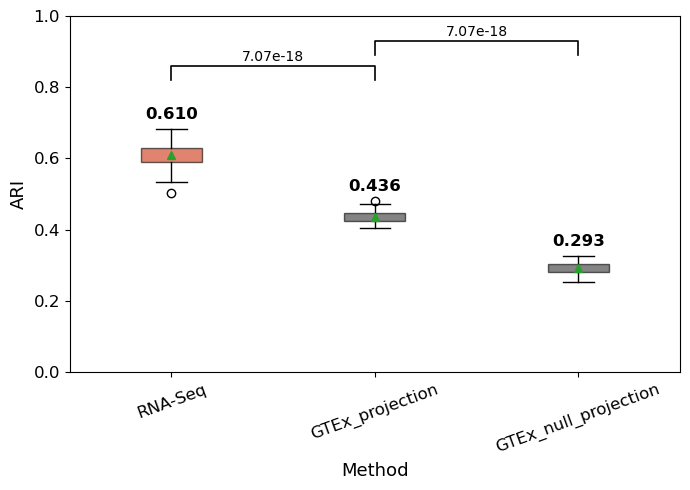

In [21]:
candidate_names = [
    "best_k_gtex_rnaseq_kmeans_results_df",
    "best_k_archs4_proj_kmeans_results_df",
    "best_k_rand_proj_kmeans_results_df",
]

display_name_map = {
    "rnaseq": "RNA-Seq",
    "archs4_proj": "GTEx_projection",
    "rand_proj": "GTEx_null_projection",
}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"^best_k_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

def get_display_name(name: str) -> str:
    return display_name_map.get(clean_name(name), clean_name(name))

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

means = {name: df["ari"].mean() for name, df in datasets.items()}
ordered_names = sorted(means, key=lambda n: means[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(7, 5))

box = ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True,
    medianprops={"visible": False},
)

for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(get_model_color(label))
    patch.set_alpha(0.6)

for i, d in enumerate(data):
    mean_ari = np.mean(d)
    max_val = np.max(d)
    ax.text(
        i + 1,
        max_val + 0.02,
        f"{mean_ari:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("ARI", fontsize=13)
ax.set_xlabel("Method", fontsize=13)
plt.xticks(rotation=20, ha="center", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Significance bars: GTEx_projection vs RNA-Seq and GTEx_projection vs GTEx_null_projection
proj_label = "GTEx_projection"
pairs = [(proj_label, "RNA-Seq"), (proj_label, "GTEx_null_projection")]

def mw_p_two(a, b):
    return mannwhitneyu(a, b, alternative="two-sided").pvalue

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}
pvals = np.array([
    mw_p_two(data[labels.index(a)], data[labels.index(b)]) for a, b in pairs
])

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.005,
        txt,
        ha="center",
        va="bottom",
        fontsize=10,
        clip_on=False,
    )

y_start = 0.82
bar_height = 0.04
gap = 0.03
y = y_start
for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Scaling approach summary

In [18]:
method_results = {
    'rnaseq':            gtex_rnaseq_results,
    'C2CP_CLAMP':        gtex_C2CP_CLAMP_results,
    'archs4_projection': archs4_proj_results,
    'archs4_randomZ':    rand_proj_results,
}

scaling_comparison = []
for method, results in method_results.items():
    scaling_comparison.append({
        'Method':        method,
        'Best Approach': results['best_approach'],
        'Best k':        results['best_k'],
        'Scaled ARI':    f"{results['scaled_ari']:.4f}",
        'Unscaled ARI':  f"{results['unscaled_ari']:.4f}",
    })

display(pd.DataFrame(scaling_comparison))

,Method,Best Approach,Best k,Scaled ARI,Unscaled ARI
0,rnaseq,scaled,25,0.6096,0.6096
1,C2CP_CLAMP,scaled,20,0.6487,0.6299
2,archs4_projection,scaled,30,0.4356,0.3162
3,archs4_randomZ,scaled,35,0.2929,0.2248
